<a href="https://colab.research.google.com/github/Liping-LZ/BDAO_DSDO_2425/blob/main/Big_data_analytics/Sentiment_analysis_using_Google_Natural_Language_API_dsdo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# First, we need to load the dataset into Google Colab.
# This statement allows you to select the file from your laptop and upload it to Google Cloud.
# Please wait until you see 100% done and the play button is resumed. it might take a while to upload because the dataset is large

# Import necessary Python libraries
from google.colab import files

#Upload the dataset to Google Colab
uploaded = files.upload()

Saving british_airways_reviews.csv to british_airways_reviews.csv


In [12]:
# once you upload the data to the cloud, you can read the data into dataframe.
# Remember, if you close the notebook or disconnect, you need to upload the file (run the code above) again before you read data.

import pandas as pd

data = 'british_airways_reviews.csv' # change the csv file name to your file name that you uploaded
df = pd.read_csv(data)
df.head()

,title,reviews,published_dates,user_name,user_location,user_ratings,trip_details,would_recommed_to_others
0,“Worst service ever”,Worst service ever. Lost baggage because of d...,23rd January 2024,Chirag Thummar,Germany,1,Type Of TravellerSolo Leisure\nSeat TypeEconom...,n
1,"""unprofessional attitude of the pilots""",BA 246 21JAN 2023 Did not appreciate the unp...,21st January 2024,D Carreno,United Kingdom,6,AircraftA350\nType Of TravellerBusiness\nSeat ...,n
2,“Next time it will be Jet2”,Not a great experience. I could not check in ...,18th January 2024,Simon Channon,United Kingdom,3,AircraftA320\nType Of TravellerCouple Leisure\...,n
3,“become the Ryanair of long-haul travel”,I was excited to fly BA as I'd not travelled ...,18th January 2024,Melissa Harris,United Kingdom,2,Type Of TravellerFamily Leisure\nSeat TypeEcon...,n
4,“They never help us”,I just want to warn everyone of the worst cu...,17th January 2024,Ivana Squassabia,Germany,1,Type Of TravellerFamily Leisure\nSeat TypeBusi...,n


In [13]:
# Change your target_column to the column with review data

target_column = 'reviews'

## **2. Text cleaning**

In [14]:
# drop data with missing values in the 'content' column (target_column)
df = df.dropna(subset=[target_column])

In [15]:
# convert the relevant column to lowercase
df[target_column] = df[target_column].str.lower()

In [16]:
# remove contraction
!pip install contractions
import contractions
df[target_column] = df[target_column].map(lambda x: contractions.fix(x))

# Remove unwanted characters/objects (e.g. url, email, emoji etc.). You don't need to run all of them, but just take the ones suitable for your case.
# import the re library. Re is a built-in python package, which can be used to work with Regular Expressions.

import re

# Remove new line characters ("/n")

df[target_column] = df[target_column].map(lambda x: re.sub('\s+', ' ', x))

# Remove url link
df[target_column] = df[target_column].apply(lambda x: re.sub('http://\S+|https://\S+', '', x))

# Remove email address
df[target_column] = df[target_column].map(lambda x: re.sub('\S*@\S*\s?', '', x))

# Remove emoji
# First, build a list of commonly used emojis
emoj = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002500-\U00002BEF"  # chinese char
        u"\U00002702-\U000027B0"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642"
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"  # dingbats
        u"\u3030"
                      "]+", re.UNICODE)

# Then remove the emoji
df[target_column] = df[target_column].map(lambda x: re.sub(emoj, ' ', x))

# Remove non-word characters, so numbers and ___ etc
df[target_column] = df[target_column].str.replace("[^A-Za-z]", " ", regex = True)

# Remove overspace
df[target_column] = df[target_column].map(lambda x: re.sub('\s{2,}', " ", x))

In [17]:
df.head()

,title,reviews,published_dates,user_name,user_location,user_ratings,trip_details,would_recommed_to_others
0,“Worst service ever”,worst service ever lost baggage because of de...,23rd January 2024,Chirag Thummar,Germany,1,Type Of TravellerSolo Leisure\nSeat TypeEconom...,n
1,"""unprofessional attitude of the pilots""",ba jan did not appreciate the unprofessional ...,21st January 2024,D Carreno,United Kingdom,6,AircraftA350\nType Of TravellerBusiness\nSeat ...,n
2,“Next time it will be Jet2”,not a great experience i could not check in o...,18th January 2024,Simon Channon,United Kingdom,3,AircraftA320\nType Of TravellerCouple Leisure\...,n
3,“become the Ryanair of long-haul travel”,i was excited to fly ba as i would not travel...,18th January 2024,Melissa Harris,United Kingdom,2,Type Of TravellerFamily Leisure\nSeat TypeEcon...,n
4,“They never help us”,i just want to warn everyone of the worst cus...,17th January 2024,Ivana Squassabia,Germany,1,Type Of TravellerFamily Leisure\nSeat TypeBusi...,n


## **3. Using Google Natural Language API to do sentiment analysis**
The powerful pre-trained models of the Natural Language API empowers developers to easily apply natural language understanding (NLU) to their applications with features including sentiment analysis, entity analysis, entity sentiment analysis, content classification, and syntax analysis.

### 3.1 Enable API and create credentials

First, you need to enable Google Natural Language API in Google Cloud. Please search for "Cloud Natural Language API" and then click "Enable". Once enabled, there should be a dashboard of API.

### 3.2 Authentication

To connect with API and interact with Google Cloud Natural Language API, we need to get authentication. We are doing the same as how we connect to Google BigQuery and Google Cloud Storage. We also explicitly tell under which project you are working.




In [7]:
# Authenticate and access Google Cloud services in google colab
from google.colab import auth
auth.authenticate_user()

In [8]:
# Replace with your actual project ID
project_id = 'your project id'
!gcloud config set project {project_id}

Updated property [core/project].


In [9]:
# Here we test with one text

from google.cloud import language_v2

def analyze_sentiment(text):
    client = language_v2.LanguageServiceClient(client_options={
        'api_endpoint': f'language.googleapis.com',
        'quota_project_id': project_id
    }
    )

    document = language_v2.Document(
        content=text,
        type_=language_v2.Document.Type.PLAIN_TEXT
    )

    sentiment = client.analyze_sentiment(
        request={"document": document}
    ).document_sentiment

    print(f"Text: {text}")
    print(f"Sentiment score: {sentiment.score:.2f} (-1.0 negative to 1.0 positive)")
    print(f"Sentiment magnitude: {sentiment.magnitude:.2f} (strength of emotion)")

    return sentiment

# Test with a sample text
analyze_sentiment("I love taking class so much!")

Text: I love taking class so much!
Sentiment score: 0.94 (-1.0 negative to 1.0 positive)
Sentiment magnitude: 0.98 (strength of emotion)


magnitude: 0.981
score: 0.945

In [10]:
# Now we will run the sentiment analysis for all reviews

import pandas as pd
from google.cloud import language_v2
import time
from tqdm.notebook import tqdm  # For progress tracking in Colab

def analyze_sentiment_batch(df, text_column, batch_size=10):
    """
    Analyze sentiment for texts in a dataframe with batching.
    No async/await is used in this function.

    Args:
        df: DataFrame containing text to analyze
        text_column: Name of the column with text content
        batch_size: Number of texts to process in each batch

    Returns:
        DataFrame with sentiment scores and magnitudes added
    """
    # Initialize the client
    client = language_v2.LanguageServiceClient(client_options={
        'api_endpoint': f'language.googleapis.com',
        'quota_project_id': project_id
    }
    )

    # Create a copy of the input dataframe
    result_df = df.copy()

    # Initialize sentiment columns
    result_df['sentiment_score'] = None
    result_df['sentiment_magnitude'] = None

    # Get list of texts to process
    texts = df[text_column].tolist()

    # Process in batches
    for i in tqdm(range(0, len(texts), batch_size), desc="Processing batches"):
        # Get current batch
        batch_indices = range(i, min(i + batch_size, len(texts)))

        # Process each text in the batch
        for idx in batch_indices:
            text = texts[idx]

            # Skip empty or non-string entries
            if pd.isna(text) or not isinstance(text, str) or text.strip() == "":
                result_df.loc[df.index[idx], 'sentiment_score'] = None
                result_df.loc[df.index[idx], 'sentiment_magnitude'] = None
                continue

            try:
                # Create document object
                document = language_v2.Document(
                    content=text,
                    type_=language_v2.Document.Type.PLAIN_TEXT
                )

                # Get sentiment
                sentiment = client.analyze_sentiment(
                    request={"document": document}
                ).document_sentiment

                # Store results
                result_df.loc[df.index[idx], 'sentiment_score'] = sentiment.score
                result_df.loc[df.index[idx], 'sentiment_magnitude'] = sentiment.magnitude

            except Exception as e:
                print(f"Error processing text at index {idx}: {str(e)}")
                result_df.loc[df.index[idx], 'sentiment_score'] = None
                result_df.loc[df.index[idx], 'sentiment_magnitude'] = None

        # Add delay between batches to avoid rate limits
        if i + batch_size < len(texts):
            time.sleep(1)  # 1.5 second delay between batches

    return result_df

In [ ]:
# call the above function and define the dataframe where contains the text content you would like to analyse
result_df = analyze_sentiment_batch(df, target_column, batch_size=100) # you can change the batch_size

In [20]:
result_df

,title,reviews,published_dates,user_name,user_location,user_ratings,trip_details,would_recommed_to_others,sentiment_score,sentiment_magnitude
0,“Worst service ever”,worst service ever lost baggage because of de...,23rd January 2024,Chirag Thummar,Germany,1,Type Of TravellerSolo Leisure\nSeat TypeEconom...,n,-0.883,0.982
1,"""unprofessional attitude of the pilots""",ba jan did not appreciate the unprofessional ...,21st January 2024,D Carreno,United Kingdom,6,AircraftA350\nType Of TravellerBusiness\nSeat ...,n,-0.902,0.976
2,“Next time it will be Jet2”,not a great experience i could not check in o...,18th January 2024,Simon Channon,United Kingdom,3,AircraftA320\nType Of TravellerCouple Leisure\...,n,-0.421,0.972
3,“become the Ryanair of long-haul travel”,i was excited to fly ba as i would not travel...,18th January 2024,Melissa Harris,United Kingdom,2,Type Of TravellerFamily Leisure\nSeat TypeEcon...,n,-0.666,0.958
4,“They never help us”,i just want to warn everyone of the worst cus...,17th January 2024,Ivana Squassabia,Germany,1,Type Of TravellerFamily Leisure\nSeat TypeBusi...,n,-0.91,0.98
...,...,...,...,...,...,...,...,...,...,...
1295,"""entertainment was not working""",my family and i travelled from cape town to l...,1st April 2018,Muhammad Kajee,United Kingdom,1,Type Of TravellerFamily Leisure\nSeat TypeEcon...,n,-0.87,0.964
1296,"""staff try so very hard to please""",gatwick to madeira the flight left on time an...,30th March 2018,P Dean,United Kingdom,4,AircraftA320\nType Of TravellerFamily Leisure\...,n,-0.317,0.971
1297,"""extremely unprofessional""",london to casablanca their customer service q...,30th March 2018,E Christie,United Kingdom,2,Type Of TravellerSolo Leisure\nSeat TypeEconom...,n,-0.861,0.981
1298,"""manager is very professional""",british airways flight manager is very profes...,28th March 2018,N Wang,Hong Kong,8,Type Of TravellerSolo Leisure\nSeat TypeEconom...,y,0.912,0.973


In [ ]:
result_df.to_csv('result.csv', index=False)
from google.colab import files
files.download('result.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Axes: xlabel='sentiment_score', ylabel='Count'>

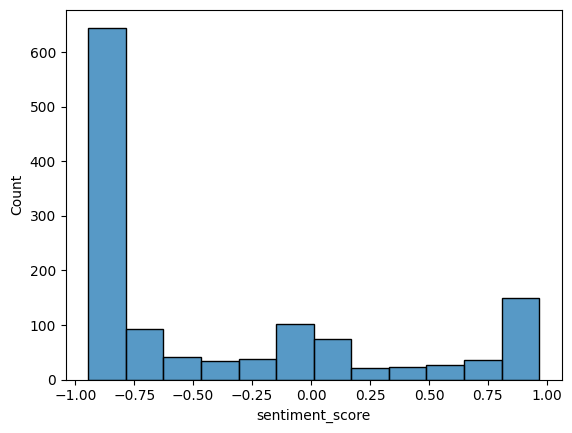

In [21]:
import matplotlib.pyplot as plt # we use this for visualisation
import seaborn as sns # we use this for visualisation

# distribution plot sentiment_score
sns.histplot(result_df['sentiment_score'])

<Axes: xlabel='user_ratings', ylabel='Count'>

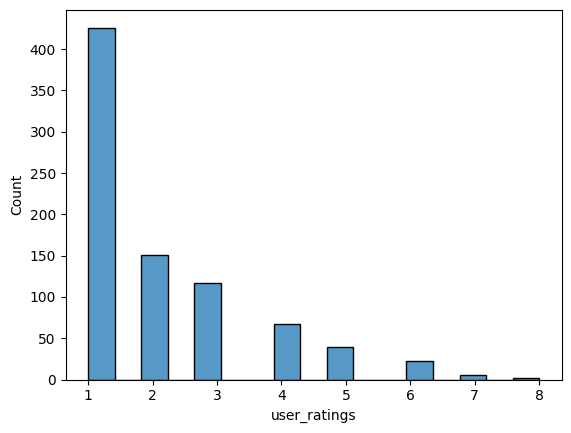

In [22]:
# plot the distribution of score while sentiment score is smaller than -0.25 (negative)
sns.histplot(result_df[result_df['sentiment_score']<-0.25]['user_ratings'])

<Axes: xlabel='user_ratings', ylabel='Count'>

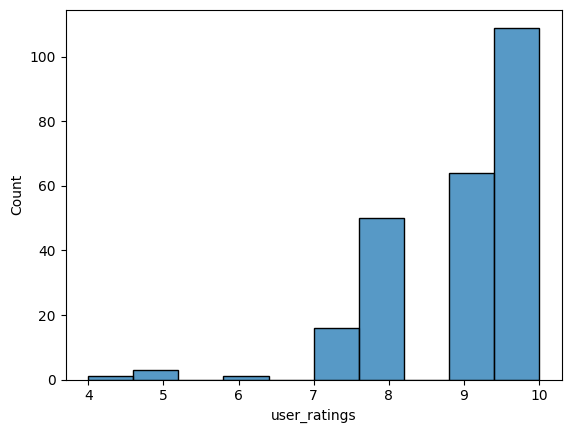

In [23]:
# plot the distribution of score while sentiment score is larger than 0.25 (positive)
sns.histplot(result_df[result_df['sentiment_score']>0.25]['user_ratings'])

Please check this link to understand how to interpret the sentiment analysis values: https://cloud.google.com/natural-language/docs/basics#interpreting_sentiment_analysis_values